<a href="https://colab.research.google.com/github/AhmedGDeeb/FTL/blob/main/tasks/FTL_Tasks_ahmad_deeb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 1.1

## Assignment: BMI Calculator and Health Assessment



**Objective:**

Build a Python program that calculates the Body Mass Index (BMI) of a user and provides a health assessment based on their BMI value.

**Background Context:**
BMI is a measure used to determine whether a person has a healthy body weight for a person of their height. It is calculated using the following formula:

$$ \text{BMI} = \frac{\text{weight in kilograms}}{\text{height in meters}^2} $$


The BMI categories are:

* Underweight: BMI is less than 18.5
* Normal weight: BMI is 18.5 to 24.9
* Overweight: BMI is 25 to 29.9
* Obesity: BMI is 30 or greater

**Tasks:**

**User Input:**

* Prompt the user to input their weight in kilograms (float).
* Prompt the user to input their height in meters (float).


**Calculate BMI:**

Using the formula provided, calculate the BMI. Store it in a variable named bmi.

**Provide Health Assessment:**

Using conditional statements (if, elif, and else), determine which BMI category the user falls into.
Print out the user's BMI and the corresponding health assessment.

**Error Handling:**

Ensure the user cannot enter a negative or zero value for height or weight. If they do, provide an error message and prompt them to enter the value again.


**Expected Output:**


Enter your weight in kilograms: 70
Enter your height in meters: 1.75

Your BMI is 22.86. You have a Normal weight.



In [ ]:
# Solution
# Version: 2.0
# Date: 17/09/2026

weight = 0
height = 0
err_msg = "{} must be a positive non-zero number, you entered {}"

while(weight <= 0):
    weight = float(input("Please enter your weight (kilograms): "))
    if weight <= 0:
        print(err_msg.format("weight", weight))

while(height <= 0):
    height = float(input("Please enter your height (meters): "))
    if height <= 0:
         print(err_msg.format("height", height))

bmi = weight / height**2

if bmi < 18.5:
    print("Your BMI is {:.2f}. You have a {}".format(bmi, "Under weight"))
elif bmi < 25:
    print("Your BMI is {:.2f}. You have a {}".format(bmi, "Normal weight"))
elif bmi < 30:
    print("Your BMI is {:.2f}. You have a {}".format(bmi, "Overweight"))
else:
    print("Your BMI is {:.2f}. You have a {}".format(bmi, "Obesity"))

# Session 1.2

## **Exercise: Design Your Own Treasure Hunt Game**

**Background**
You're tasked with creating a simple board game. In this game, players are treasure hunters, and they need a board to visualize where they might find hidden treasures. Your job is to create this board and allow players to place the treasure at a location of their choice.

**Objectives**
Board Creation: Create a grid or board of size n x m, where n represents the number of rows and m represents the number of columns. The board should be filled with asterisks (*), which symbolize empty spaces.
Player Interaction: Prompt the user (player) to specify a location (row and column) to hide the treasure.

Board Display: Using nested loops, construct and display the game board. Use an asterisk (*) for empty cells and a T for the cell with the treasure.


**Requirements**
The program should start by asking the player to specify the size of the board by entering the number of rows (n) and columns (m).
After creating the board, prompt the player to specify where they want to hide the treasure. Make sure they provide a valid row and column number.
Handle potential input errors gracefully. For example, if the user tries to place the treasure outside the board's dimensions, display an error message and ask them to enter a valid location.


**Bonus Challenge**
Add a Trap: Randomly place a trap (X) on the board in addition to the treasure. Ensure that the trap does not overlap with the treasure.
Player Guess: Ask the player to guess the location of the treasure. If they find it, display a winning message. If they land on the trap, display a message that they've been trapped. Otherwise, inform them to try again.

In [4]:
# Version: 1.0
# Date: 17/09/2026

import random


def get_positive_int(prompt):
    """Prompt for a positive integer, re-asking on bad input."""
    while True:
        raw = input(prompt).strip()
        try:
            value = int(raw)
        except ValueError:
            print("'{}' is not a valid integer. Try again.".format(raw))
            continue
        if value <= 0:
            print("Value must be a positive non-zero number, you entered {}".format(value))
            continue
        return value


def get_position(prompt, n, m):
    """Prompt for a (row, col) within an n x m board, 1-indexed."""
    while True:
        raw = input(prompt).strip()
        parts = raw.split()
        if len(parts) != 2:
            print("Please enter two numbers separated by a space (e.g. '2 3').")
            continue
        try:
            row, col = int(parts[0]), int(parts[1])
        except ValueError:
            print("Both values must be integers.")
            continue
        if not (1 <= row <= n) or not (1 <= col <= m):
            print("Out of bounds. Row must be 1-{}, column must be 1-{}.".format(n, m))
            continue
        return row - 1, col - 1   # convert to 0-indexed


def create_board(n, m, fill="*"):
    """Build an n x m board filled with `fill`, using nested loops."""
    board = []
    for i in range(n):
        row = []
        for j in range(m):
            row.append(fill)
        board.append(row)
    return board


def display_board(board):
    """Print the board using nested loops."""
    n = len(board)
    m = len(board[0])
    # column header
    print("    " + " ".join(str(c + 1) for c in range(m)))
    print("   " + "-" * (2 * m))
    for i in range(n):
        row_str = ""
        for j in range(m):
            row_str += board[i][j] + " "
        print("{:2d}| {}".format(i + 1, row_str))


def place_trap(board, treasure_pos):
    """Place a single 'X' on a random empty cell (not the treasure)."""
    n = len(board)
    m = len(board[0])
    empty = [(i, j) for i in range(n) for j in range(m)
             if (i, j) != treasure_pos]
    if not empty:
        return None
    trap_pos = random.choice(empty)
    board[trap_pos[0]][trap_pos[1]] = "X"
    return trap_pos


def hide(board, pos, symbol):
    board[pos[0]][pos[1]] = symbol


def play_guessing_game(board, treasure_pos, trap_pos):
    """Bonus: let the player guess until they find the treasure or hit the trap."""
    while True:
        row, col = get_position(
            "Guess the treasure location (row col): ",
            len(board), len(board[0])
        )
        pos = (row, col)

        if pos == treasure_pos:
            print("You found the treasure! You win!")
            return
        elif pos == trap_pos:
            print("You've been trapped! Game over.")
            return
        else:
            print("Nothing here... try again.")


def main():
    print("=== Treasure Hunter ===")

    # 1. Board size
    n = get_positive_int("Enter number of rows (n): ")
    m = get_positive_int("Enter number of columns (m): ")

    # 2. Create empty board
    board = create_board(n, m)

    # 3. Ask where to hide the treasure
    print("\nWhere do you want to hide the treasure? (row and column, 1-{})".format(
        "{}".format(n) + " / 1-" + str(m)))
    t_row, t_col = get_position("Treasure location (row col): ", n, m)
    treasure_pos = (t_row, t_col)

    # Place treasure
    hide(board, treasure_pos, "T")

    # Bonus: place a trap that doesn't overlap the treasure
    trap_pos = place_trap(board, treasure_pos)
    if trap_pos is None:
        print("(Board too small for a trap — skipping trap placement.)")

    # Show board WITH treasure visible (the "hiding" view for the designer)
    print("\nBoard with your treasure hidden:")
    display_board(board)

    # Bonus: hide the treasure/trap for the guessing phase
    print("\nNow let's play! The treasure 'T' and any trap are hidden.\n")
    hidden_board = create_board(n, m)
    display_board(hidden_board)
    play_guessing_game(hidden_board, treasure_pos, trap_pos)


main()

=== Treasure Hunter ===
Enter number of rows (n): 3
Enter number of columns (m): 4

Where do you want to hide the treasure? (row and column, 1-3 / 1-4)
Treasure location (row col): 1
Please enter two numbers separated by a space (e.g. '2 3').
Treasure location (row col): 1 2

Board with your treasure hidden:
    1 2 3 4
   --------
 1| * T * * 
 2| * * * * 
 3| * * * X 

Now let's play! The treasure 'T' and any trap are hidden.

    1 2 3 4
   --------
 1| * * * * 
 2| * * * * 
 3| * * * * 
Guess the treasure location (row col): 3
Please enter two numbers separated by a space (e.g. '2 3').
Guess the treasure location (row col): 2 4
Nothing here... try again.
Guess the treasure location (row col): 3
Please enter two numbers separated by a space (e.g. '2 3').
Guess the treasure location (row col): 3 4
💀 You've been trapped! Game over.


**Tips**

* Utilize nested loops for constructing the game board.
* Integrate conditional statements to determine the content to display in each cell of the board.

**Sample Output**

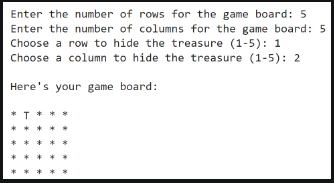

# Exercise: Building a BMI Calculator Using Functions

**Objective:**
To test your understanding of functions in Python, you are required to build a BMI (Body Mass Index) calculator.

**Background:**

The Body Mass Index (BMI) is a number calculated from a person's weight and height. It can be used to screen for weight categories that may lead to health problems.

The BMI is defined as:

$$ \text{BMI} = \frac{\text{weight in kilograms}}{\text{height in meters}^2} $$

**Requirements:**

* Function Name: Your function should be named calculate_bmi.
* Parameters: The function should accept two parameters:
>weight: The weight of the person in kilograms.\
height: The height of the person in meters.

* Return Value: The function should return the calculated BMI value rounded to two decimal places.
* User Input: After defining the function, prompt the user to input their weight and height.

**Output:** Display the calculated BMI to the user along with a health category:The BMI categories are:

* Underweight: BMI is less than 18.5
* Normal weight: BMI is 18.5 to 24.9
* Overweight: BMI is 25 to 29.9
* Obesity: BMI is 30 or greater


**Bonus Challenge**
Extend your program to also accept weight in pounds and height in inches. Convert these values to kilograms and meters respectively, before calculating the BMI. Remember:

1 kilogram is approximately 2.20462 pounds.
1 meter is approximately 39.3701 inches.

In [3]:
# Solution
# Version: 1.0
# Date: 17/09/2026

# utils
bmi_calculator = lambda weight, height: weight / height**2
pounds_to_kg = lambda pounds: pounds / 2.20462
inches_to_m = lambda inches: inches / 39.3701

def bmi_health_cateogry(bmi):
    if bmi < 18.5:
        return "Under weight"
    elif bmi < 25:
        return "Normal weight"
    elif bmi < 30:
        return "Overweight"
    return "Obesity"

# cli general utils
def get_cli_input(prompt, validation_func, choices=None):
    if choices != None: default = choices[0]
    while True:
        raw = input(prompt).strip().lower()
        if raw == "":
            print("Using default choice: {}".format(default))
            return default
        is_valid, err_msg = validation_func(raw)
        if is_valid:
            return raw
        print(err_msg)


_positive_non_zero = lambda value, label:  "" if value > 0 else f"Invalid input for {label}!!! \n It must be a positive non-zero number, you entered {value}"
def cli_get_positive_non_zero(prompt, label):
    value = 0
    while(value <= 0):
        value = float(input(prompt))
        err_msg = _positive_non_zero(value, label)
        if err_msg != "":
            print(err_msg)
    return value

_valid_choice = lambda choice, choices: "" if choice in choices else f"Invalid input!!! \n It must be one from the options <{choices}>, you entered {choice}"
def cli_get_valid_choice(prompt, label):
    value = 0
    while(value <= 0):
        value = float(input(prompt))
        err_msg = _positive_non_zero(value, label)
        if err_msg != "":
            print(err_msg)
    return value

# task specific cli input
def cli_input():
    # get weight unit
    weight = cli_get_positive_non_zero("Please enter your height (meters): ", "weight")
    weight_unit = None

    # get height unit
    height = cli_get_positive_non_zero("Please enter your height (meters): ", "height")
    height_unit = None

    return weight, height

# task specific cli output
def cli_output(bmi, health_cateogry):
    print("Your BMI is {:.2f}. You have a {}".format(bmi, health_cateogry))

# C/C++ style program
def main():
    # handle user input
    weight, height = cli_input()

    # calculate bmi
    bmi = bmi_calculator(weight, height)

    # get health category
    health_cateogry = bmi_health_cateogry(bmi)

    # output result
    cli_output(bmi, health_cateogry)

main()

Please enter your height (meters): 1
Please enter your height (meters): 5
Your BMI is 0.04. You have a Under weight


# Session 2

## **Exercise: Palindrome Checker**

Objective: Write a program to determine if a given word or sentence is a palindrome. A palindrome is a word, phrase, number, or other sequences of characters that reads the same forward and backward (ignoring spaces, punctuation, and capitalization).

Instructions:

Your program should be able to ignore non-alphanumeric characters and be case insensitive. For example, "A man, a plan, a canal, Panama" is a valid palindrome.

Create two functions to check for palindromes:

is_palindrome_while(input_string: str) -> bool: This function should use a while loop to check if the input string is a palindrome.
is_palindrome_for(input_string: str) -> bool: This function should use a for loop to check if the input string is a palindrome.
Both functions should return True if the input string is a palindrome and False otherwise.

Test your functions with some sample inputs. Remember, your functions should be able to handle cases with spaces and punctuation.

Hints:

Consider using Python string methods and conditional checks to clean your input string.
To check the palindrome property, consider how you might compare characters from the beginning and end of the string, moving inward.

```python
def is_polindrome_while(input_string: str) -> bool:
    
    input_string = ''.join(c for c in input_string if c.isalnum()).lower()
    
    left = 0
    right = len(input_string) - 1
    
    while left < right:
        if input_string[left] !=input_string[right]:
            return False
        left +=1
        right -=1
        
    return True

print(is_polindrome_while("A man, a plan, a canal, Panama" ))
```

In [ ]:
def is_polindrome_for(input_string: str) -> bool:
    
    input_string = ''.join(c for c in input_string if c.isalnum()).lower()
    
    for left in range(0, len(input_string)):
        if input_string[left] != input_string[len(input_string) - left - 1]:
            return False
        
    return True

print(is_polindrome_for("A man, a plan, a canal, Panama" ))